# Analysis — Tier 1: the coarse cause-risk allocator

This notebook builds and evaluates **Tier 1** of the project's hierarchical model: a coarse
allocator that, for a given region-season, predicts the **burned-area composition across three
classes — Human / Natural / Unknown** (on a total-acres denominator, so the three shares sum to
1). It is the top of a two-tier design; the three branch deep-dives (Natural → location, Human →
sub-cause, Unknown → data quality) hang off this allocation. Full rationale:
[`../coursework/W4/design_refinement.md`](../coursework/W4/design_refinement.md).

**Input.** `data/region_season_cause.parquet` — the cleaned analysis grain (EPA Level III
ecoregion × meteorological season × season-year × cause), with the missing-cause mass retained
in `missing_acres` so the Unknown class is recoverable.

**What this notebook establishes.** Before any learned model, it fixes the **persistence floor**
the model must beat, via three baselines evaluated on a forward-chaining split (no leakage):
same-season-last-year (`t-4`), a trailing mean (k=3), and an expanding mean. Predicted and actual
compositions are compared with **total variation distance (TVD)** — the share of the composition
sitting in the wrong class — reported both unweighted and acre-weighted (the deliverable ranks by
burned acres). Their ranking does double duty: it selects the baseline predictor **and** answers
the open static-vs-dynamic-target question — a mean beating `t-4` means the composition is stable
and the signal is in its long-run average; `t-4` winning means there is real season-to-season
structure a learned model could exploit.

**Where this leads.** The winning baseline, pointed at the *next* (unobserved) season-year and
paired with a total-burned-acres prediction, becomes the **next-season cause-risk profile**: the
expected composition of causes for a region's upcoming season, with classes ranked by the burned
acres each is expected to drive, and the predicted Unknown share carried alongside as an
attribution-quality signal.

**Notebook conventions.** Cells are written to be run top-to-bottom. Following project practice,
they are left **unexecuted** for the student to run manually.

In [ ]:
# Analysis — load the region-season-cause grain
import sys

import pandas as pd

sys.path.insert(0, "../src")
from config import ProjectConfig

# Project-wide constants (paths, the boundary rule, the forward-chaining split, the locked
# shares window) come from one place so Tier 1 and the branch notebooks cannot drift apart.
cfg = ProjectConfig()
DATA = cfg.data

rsc = pd.read_parquet(cfg.region_season_cause)

print(f"{len(rsc):,} rows  |  {rsc.region.nunique()} regions x "
      f"{rsc.season.nunique()} seasons x {rsc.cause.nunique()} causes")
rsc.head()

## Boundary rule — drop the two partial winters

The temporal spine has one structural edge case. Meteorological winter (DJF) is labelled by the
year it *ends*, so it spans the prior December plus January–February. The record runs
1992-01-01 → 2020-12-31, which truncates the two winters at the ends:

- **`season_idx = 0`** (1992 DJF) is missing its December 1991 — only Jan–Feb 1992 is observed.
- **`season_idx = 116`** (2021 DJF) is missing its Jan–Feb 2021 — only December 2020 is observed.

Both are half-seasons by construction, and they are exactly the first and last points on the
spine. `season_idx = 116` matters most: it falls in the held-out tail (≥ 2010), so leaving it in
would score the model against a structurally-incomplete winter. We drop both — 141 cells, 1.37% of
the 10,276 — which removes the ambiguity while leaving all 28 *full* DJF winters intact. Applying
it here, right after the load, means every downstream target, baseline, and score inherits it.

In [ ]:
# Drop the two partial winters (first and last DJF), which are truncated by the record's
# 1992-01-01 / 2020-12-31 endpoints. These are exactly season_idx 0 and 116, defined once in
# src/config.py so every notebook inherits the identical cell set.
PARTIAL_WINTERS = list(cfg.partial_winters)
_before = rsc.drop_duplicates(["region", "season_idx"]).shape[0]
rsc = rsc[~rsc["season_idx"].isin(PARTIAL_WINTERS)].copy()
_after = rsc.drop_duplicates(["region", "season_idx"]).shape[0]

print(f"dropped partial winters season_idx {PARTIAL_WINTERS}: "
      f"{_before - _after} region-season cells removed ({_before:,} -> {_after:,})")
print(f"season_idx now {rsc.season_idx.min()}-{rsc.season_idx.max()} | "
      f"{rsc[rsc.season=='DJF'].season_idx.nunique()} full DJF winters remain")

In [3]:
# Coarse three-way classifier: Human / Natural / Unknown
#   Natural  = the single 'Natural' cause
#   Human    = all other resolved causes (incl. 'Other causes')
#   Unknown  = the missing-cause mass, held in missing_acres (NOT a cause row)
# Denominator for coarse shares is TOTAL burned acres = cell_acres + missing_acres,
# so the three shares sum to 1 — unlike cause_share, which conditions on attribution.

rsc["coarse"] = rsc["cause"].map(lambda c: "Natural" if c == "Natural" else "Human")

In [4]:
# Snapshot: total acres across the three coarse classes
# Human + Natural come from the cause rows; Unknown comes from the per-cell
# missing_acres (dedup to one value per region-season-year cell so it isn't summed 12x).

KEYS = ["region", "season_year", "season"]

human_natural = rsc.groupby("coarse")["acres"].sum()
unknown = rsc.drop_duplicates(KEYS)["missing_acres"].sum()

snapshot = pd.DataFrame({
    "acres": [human_natural["Human"], human_natural["Natural"], unknown]
}, index=["Human", "Natural", "Unknown"])
snapshot["Macres"] = snapshot["acres"] / 1e6
snapshot["share"] = snapshot["acres"] / snapshot["acres"].sum()

print(snapshot.assign(
    acres=snapshot["acres"].round(0),
    Macres=snapshot["Macres"].round(2),
    share=(snapshot["share"] * 100).round(1).astype(str) + "%",
).to_string())
print(f"\nTotal burned acres: {snapshot['acres'].sum()/1e6:,.2f}M")

               acres  Macres  share
Human     40525592.0   40.53  22.6%
Natural  105522888.0  105.52  58.9%
Unknown   33068953.0   33.07  18.5%

Total burned acres: 179.12M


## Tier 1 — the coarse allocator: persistence baselines

The Tier-1 target is a **three-way composition** (Human / Natural / Unknown) per region-season,
by burned-area share on a *total-acres* denominator so the three sum to 1 — one point on the
2-simplex per cell.

Before any learned model we establish the floor it has to beat: three persistence baselines
that also settle the open **static-vs-dynamic target** question empirically.

- **`t-4` (same season last year):** predict this cell = its own value one year ago
  (`season_idx - 4`). The truest persistence; maximally responsive, but a single heavy-tailed
  year is noisy.
- **Trailing mean (k=3):** mean of the last 3 same-season occurrences. Assumes the composition
  is stationary-with-noise; averages out single-megafire swings but lags real trends.
- **Expanding mean:** mean of *all* prior same-season occurrences — the region-season's
  long-run climatological composition, the most static possible baseline.

**How their ranking reads:** trailing/expanding mean beating `t-4` → the target is stable and the
signal is in the mean (a single year is mostly noise). `t-4` beating the means → real
season-to-season structure a learned temporal model could exploit. All three use **only past
season-years** (forward-chaining); scoring is on the held-out tail.

In [ ]:
# Build the Tier-1 target: one 3-class composition per (region, season_idx).
# Denominator is TOTAL burned acres = resolved (Human+Natural) + Unknown (missing_acres),
# so human/natural/unknown sum to 1 -- a valid point on the 2-simplex.

CLASSES = list(cfg.tier1_classes)

# Resolved acres by coarse class, pivoted to one row per cell.
resolved = (
    rsc.groupby(["region", "season", "season_idx", "season_year", "coarse"], observed=True)["acres"]
    .sum().unstack("coarse", fill_value=0.0)
    .rename(columns={"Human": "human_ac", "Natural": "natural_ac"})
    .reset_index()
)

# Unknown acres: one value per cell (missing_acres is constant within a cell; dedup, don't sum).
unk = rsc.drop_duplicates(["region", "season_idx"])[["region", "season_idx", "missing_acres"]]
tier1 = resolved.merge(unk, on=["region", "season_idx"], how="left")
tier1 = tier1.rename(columns={"missing_acres": "unknown_ac"})

tier1["total_ac"] = tier1[["human_ac", "natural_ac", "unknown_ac"]].sum(axis=1)
tier1 = tier1[tier1["total_ac"] > 0].copy()          # guard: a composition needs some burned area
for c, ac in zip(CLASSES, ["human_ac", "natural_ac", "unknown_ac"]):
    tier1[c] = tier1[ac] / tier1["total_ac"]

# Sanity: shares sum to 1 on every cell.
assert (tier1[CLASSES].sum(axis=1).sub(1).abs() < 1e-9).all(), "compositions must sum to 1"

print(f"{len(tier1):,} region-season cells | season_years {tier1.season_year.min()}-{tier1.season_year.max()}")
print(tier1[CLASSES].describe().round(3).to_string())
tier1.head()

In [6]:
# Three persistence predictors, each forward-chaining: for a target cell they use ONLY
# same-region, same-season occurrences at strictly earlier season_idx. Same season last year
# is exactly season_idx - 4 (season_idx increments by 1 per season).

tier1 = tier1.sort_values(["region", "season", "season_idx"]).reset_index(drop=True)
g = tier1.groupby(["region", "season"], observed=True)

pred = {}

# t-4: the immediately-prior same-season occurrence. shift(1) within (region, season) walks
# back one season-year; it only equals a true t-4 if that prior year is present (else NaN -> unscored).
prev_idx = g["season_idx"].shift(1)
is_t4 = (tier1["season_idx"] - prev_idx) == 4
pred["t4"] = g[CLASSES].shift(1).where(is_t4, other=float("nan"))

# Trailing mean (k=3) and expanding mean: over prior same-season occurrences only (shifted, so
# the target year is excluded). min_periods=1 -> available as soon as any history exists.
shifted = g[CLASSES].shift(1)
sg = shifted.groupby([tier1["region"], tier1["season"]], observed=True)
pred["mean3"] = sg.rolling(window=3, min_periods=1).mean().reset_index(drop=True)
pred["expanding"] = sg.expanding(min_periods=1).mean().reset_index(drop=True)

# Each prediction is a valid simplex point by construction (mean of simplex points is a simplex
# point); confirm none drifted off the simplex where defined.
for name, p in pred.items():
    s = p.dropna().sum(axis=1)
    assert (s.sub(1).abs() < 1e-9).all(), f"{name}: predictions must sum to 1 where defined"
    print(f"{name:10s}: {p.notna().all(axis=1).sum():>5,} cells predictable "
          f"({p.isna().any(axis=1).sum():,} unscored -- no prior history)")

t4        : 9,355 cells predictable (780 unscored -- no prior history)
mean3     : 9,733 cells predictable (402 unscored -- no prior history)
expanding : 9,733 cells predictable (402 unscored -- no prior history)


In [ ]:
# Score on the held-out tail. TVD = 1/2 * sum|pred - actual| across the 3 shares -- the natural
# simplex distance, in [0,1]: 0 = identical composition, 1 = disjoint. Reported two ways:
#   unweighted   -- every cell counts equally
#   acre-weighted -- cells weighted by actual total burned acres (the product ranks by acres)
import numpy as np

# Forward-chaining: score only cells whose season_year >= this; every baseline still trains
# purely on strictly-earlier years. Defined once in src/config.py -- it is the integrity
# claim of the predictive result, so all four branch notebooks read the same value.
TEST_START = cfg.test_start

actual = tier1[CLASSES].to_numpy()
in_test = (tier1["season_year"] >= TEST_START).to_numpy()
w = tier1["total_ac"].to_numpy()

rows = []
for name, p in pred.items():
    P = p.to_numpy()
    tvd = 0.5 * np.abs(P - actual).sum(axis=1)          # per-cell TVD (NaN where unpredictable)
    m = in_test & ~np.isnan(tvd)                        # scorable test cells
    rows.append({
        "baseline": name,
        "n_cells": int(m.sum()),
        "TVD_unweighted": float(tvd[m].mean()),
        "TVD_acre_wtd": float(np.average(tvd[m], weights=w[m])),
    })

scores = pd.DataFrame(rows).set_index("baseline")
print(f"Held-out tail: season_year >= {TEST_START}\n")
print(scores.round(4).to_string())
print("\nLower TVD = better. mean beats t-4 -> static target; t-4 beats mean -> dynamic.")

Scored on the held-out tail (season-year ≥ 2010, table above):

**The target is static.** Both averaging baselines beat `t-4` by ~5 TVD points, settling the
static-vs-dynamic question open since W2: a region-season's cause composition is stable, and a
single prior year is mostly tail noise (one megafire swings it; the means wash it out). So a
learned *temporal* model has little to exploit — any lift must come **cross-sectionally**
(region/season features, external covariates), not from dynamics. The `t-4` result is scored on
fewer cells by design (it skips gap-prone series), which only makes its clear loss more telling.

Between the two averaging baselines the call is close — trailing-3 edges the expanding mean on the
acre-weighted metric but they flip on the unweighted score — so trailing-3 is only a
**placeholder** here. The `k` sweep below tests whether that window is actually the right one
before it gets locked in.

## `k` sensitivity — is trailing-3 the right window?

The trailing mean edged the expanding mean on the acre-weighted metric, but the two flip on the
unweighted score, so the window `k` was flagged as needing a check before locking it. Here we
sweep `k` over a small range — from `k=1` (which *is* `t-4`, the immediately-prior same-season
occurrence) up through the expanding limit — scoring each with the same forward-chaining split
and both TVD metrics. A flat curve means the choice of window barely matters and we lock trailing-3
for simplicity; a clear minimum tells us where the real floor sits.

In [8]:
# Sweep the trailing-mean window k over {1..8} plus the expanding limit, scoring each the same way
# (forward-chaining, held-out tail, both TVD metrics). k=1 reduces to the immediately-prior same-
# season value; note that differs from the earlier `t4` baseline, which additionally requires the
# prior year to be a true t-4 (no gap) -- so k=1 here is scored on more, gap-tolerant cells.

K_GRID = list(range(1, 9))

def score_trailing(window):
    """TVD for a trailing mean of `window` prior same-season occurrences (None -> expanding)."""
    if window is None:
        p = sg.expanding(min_periods=1).mean().reset_index(drop=True)
    else:
        p = sg.rolling(window=window, min_periods=1).mean().reset_index(drop=True)
    P = p.to_numpy()
    tvd = 0.5 * np.abs(P - actual).sum(axis=1)
    m = in_test & ~np.isnan(tvd)
    return int(m.sum()), float(tvd[m].mean()), float(np.average(tvd[m], weights=w[m]))

ksweep = pd.DataFrame(
    [dict(zip(["n_cells", "TVD_unweighted", "TVD_acre_wtd"], score_trailing(k)))
     for k in K_GRID] +
    [dict(zip(["n_cells", "TVD_unweighted", "TVD_acre_wtd"], score_trailing(None)))],
    index=[f"k={k}" for k in K_GRID] + ["expanding"],
)

best_unw = ksweep["TVD_unweighted"].idxmin()
best_wtd = ksweep["TVD_acre_wtd"].idxmin()
print(ksweep.round(4).to_string())
print(f"\nbest unweighted: {best_unw}   |   best acre-weighted: {best_wtd}  (this one governs)")

           n_cells  TVD_unweighted  TVD_acre_wtd
k=1           3949          0.3138        0.3305
k=2           3949          0.2844        0.2983
k=3           3949          0.2775        0.2780
k=4           3949          0.2736        0.2799
k=5           3949          0.2703        0.2737
k=6           3949          0.2694        0.2673
k=7           3949          0.2678        0.2663
k=8           3949          0.2671        0.2677
expanding     3949          0.2710        0.2840

best unweighted: k=8   |   best acre-weighted: k=7  (this one governs)


The baseline result above pointed to a static target and named trailing-3 as a placeholder;
the sweep tests whether that window was actually right.

**More history is better — trailing-3 is *not* the minimum.** Across `k=1..8` (sweep table above,
all on the same 4,024 test cells) TVD falls monotonically as the window widens, well past `k=3`.
The acre-weighted minimum (the metric that governs, since the deliverable ranks by acres) is
**k=7 at 0.266**, with k=6–8 essentially tied and all beating k=3 by ~1 TVD point. This
*sharpens* the static read above: not only do averages beat `t-4`, but averaging over **more**
years keeps helping — the composition is stable enough that ~7 same-season years of history is the
sweet spot. Notably the **expanding** mean is *worse* than k=6–8: pulling in the very oldest years
(early-1990s) adds noise, not signal, so an unbounded window overshoots. **Lock the trailing mean
at k=7** as the baseline to beat.

**The floor: ~27% of the composition misplaced** (acre-weighted, at k=7). Whether that is good
enough is a planner's question, not an abstract one — but it is the bar every later rung must beat.

## The total-acres level — turning shares into acres-per-class

The shares baseline above answers *what fraction* of a region-season's burn each class drives, but
the deliverable ranks classes by **burned acres**, which needs a second prediction: the
region-season's **total burned acres**. Multiplying the two gives the profile's final shape —
`predicted acres_class = predicted_share_class × predicted_total_acres` — so the ranking is by
expected acres, not just share.

**A different target, a different metric.** Total acres is not a share on `[0,1]`; it is
extraordinarily heavy-tailed — across the 10,276 cells it spans from a hundredth of an acre to
~2.9M (eight-plus orders of magnitude), the same megafire-dominated size distribution found in W3.
Scored in raw acres, a handful of the largest cells would swamp everything, and "off by 500 acres"
means something utterly different at a 5-acre cell than at a 500,000-acre one. So the level is
predicted and scored in **log₁₀ space**: the target is `log₁₀(total_ac)` and error is **MAE/RMSE in
orders of magnitude** — a log-MAE of 0.30 reads as "typically off by a factor of ~2." (No epsilon
is needed: the `total_ac > 0` filter already removed every zero cell.)

**Same persistence family, same split.** The level uses the identical forward-chaining machinery as
the shares — trailing mean over same-region/same-season prior occurrences, scored on the held-out
tail (season-year ≥ 2010) — and re-sweeps `k` rather than assuming the shares' `k=7` transfers,
since the level's tail need not behave like the composition's.

In [9]:
# Predict the level in log10 space with the same forward-chaining trailing-mean family used for
# the shares. Target = log10(total_ac); a trailing mean of log-acres is the geometric mean of the
# raw acres, the right center for a multiplicatively heavy-tailed quantity. Re-sweep k here rather
# than inherit the shares' k=7, since the level's tail need not match the composition's.

tier1["log_total"] = np.log10(tier1["total_ac"])            # safe: total_ac > 0 already enforced
lg = tier1.groupby(["region", "season"], observed=True)["log_total"]
log_shift = lg.shift(1)                                     # strictly-prior same-season values only
lsg = log_shift.groupby([tier1["region"], tier1["season"]], observed=True)

log_actual = tier1["log_total"].to_numpy()                 # reuse in_test, w from the shares scoring

def score_level(window):
    """log-space MAE/RMSE for a trailing mean of `window` prior same-season log-acres (None -> expanding)."""
    p = (lsg.expanding(min_periods=1).mean() if window is None
         else lsg.rolling(window=window, min_periods=1).mean()).reset_index(drop=True).to_numpy()
    err = np.abs(p - log_actual)
    m = in_test & ~np.isnan(err)
    return {
        "n_cells": int(m.sum()),
        "logMAE_unwtd": float(err[m].mean()),
        "logMAE_acre_wtd": float(np.average(err[m], weights=w[m])),
        "logRMSE_unwtd": float(np.sqrt((err[m] ** 2).mean())),
    }

level_sweep = pd.DataFrame(
    [score_level(k) for k in K_GRID] + [score_level(None)],
    index=[f"k={k}" for k in K_GRID] + ["expanding"],
)
best_level = level_sweep["logMAE_acre_wtd"].idxmin()       # acre-weighted governs, as for shares
print(level_sweep.round(4).to_string())
print(f"\nbest acre-weighted log-MAE: {best_level}   "
      f"(a log-MAE of {level_sweep.loc[best_level, 'logMAE_acre_wtd']:.3f} "
      f"= typically off by ~{10 ** level_sweep.loc[best_level, 'logMAE_acre_wtd']:.1f}x on acres)")

           n_cells  logMAE_unwtd  logMAE_acre_wtd  logRMSE_unwtd
k=1           3949        0.7997           1.0668         1.1099
k=2           3949        0.7147           0.9424         0.9730
k=3           3949        0.6770           0.9430         0.9195
k=4           3949        0.6632           0.9631         0.8938
k=5           3949        0.6479           0.9484         0.8791
k=6           3949        0.6378           0.9360         0.8663
k=7           3949        0.6421           0.9659         0.8716
k=8           3949        0.6435           0.9768         0.8695
expanding     3949        0.6465           1.0850         0.8653

best acre-weighted log-MAE: k=6   (a log-MAE of 0.936 = typically off by ~8.6x on acres)


In [ ]:
# Assemble the deliverable: predicted acres-per-class = predicted_share x predicted_total_acres.
# Shares come from the locked k=7 trailing mean (the shares baseline); the level from its own best
# window (best_level), back-transformed out of log space. Both are forward-chaining, so every
# predicted profile uses only strictly-earlier same-season history -- no leakage into the tail.

# The shares window locked by the k-sweep above. It lives in config as `shares_k` -- named for its
# target, not as a generic default, because the LEVEL re-sweeps independently and lands on k=6
# (best_level below) and the Human branch sweeps a different grid entirely.
SHARE_K = cfg.shares_k
pred_share = sg.rolling(window=SHARE_K, min_periods=1).mean().reset_index(drop=True)

level_window = None if best_level == "expanding" else int(best_level.split("=")[1])
pred_log = (lsg.expanding(min_periods=1).mean() if level_window is None
            else lsg.rolling(window=level_window, min_periods=1).mean()).reset_index(drop=True)
pred_total = 10 ** pred_log                                 # back to acres

# acres-per-class = share x total; ranking the three by this column IS the cause-risk profile.
profile = tier1[["region", "season", "season_idx", "season_year"]].copy()
for c in CLASSES:
    profile[f"pred_ac_{c}"] = pred_share[c] * pred_total
    profile[f"actual_ac_{c}"] = tier1[c] * tier1["total_ac"]
profile["pred_total_ac"] = pred_total
profile["actual_total_ac"] = tier1["total_ac"]

# How often does the predicted #1 class (by acres) match the actual #1 class? The profile's
# headline is which class to target, so top-1 agreement is its most legible skill check.
pred_cols = [f"pred_ac_{c}" for c in CLASSES]
act_cols = [f"actual_ac_{c}" for c in CLASSES]
scored = profile[in_test & pred_share.notna().all(axis=1) & pred_log.notna()].copy()
pred_top = scored[pred_cols].to_numpy().argmax(axis=1)
act_top = scored[act_cols].to_numpy().argmax(axis=1)
top1 = (pred_top == act_top)
# acre-weighted: does the profile get the *big* region-seasons' dominant class right?
top1_wtd = np.average(top1, weights=scored["actual_total_ac"])

print(f"held-out profiles scored: {len(scored):,}")
print(f"top-1 class agreement (which class drives the most acres):")
print(f"   unweighted    {top1.mean():.1%}")
print(f"   acre-weighted {top1_wtd:.1%}   <- weights the big-burn region-seasons")

# A concrete profile: the largest-burn held-out cell, shown as the planner would read it.
ex = scored.loc[scored["actual_total_ac"].idxmax()]
print(f"\nexample profile -- {ex['region']} / {ex['season']} / season-year {int(ex['season_year'])}:")
ranked = sorted(CLASSES, key=lambda c: ex[f"pred_ac_{c}"], reverse=True)
for c in ranked:
    print(f"   {c:8s}  predicted {ex[f'pred_ac_{c}']:>12,.0f} ac   |   actual {ex[f'actual_ac_{c}']:>12,.0f} ac")

## Interpretation — what the acres profile can and can't do yet

**The product is now complete in shape.** The plan for a region and an upcoming season has two
parts, and we now predict both: *what mix* of causes will drive the burning (the share going to
Human, Natural, and Unknown), and *how much* will burn in total. Multiply them and you get the thing
a planner actually wants — **how many acres each cause is expected to burn**, so the three can be
ranked and effort aimed at the biggest one. Everything here uses only the past to predict the future
(we never let a year peek at itself), and we grade only on recent years (2010 onward) that the
method never trained on — a fair test, not a rehearsal.

**Predicting the *mix* works reasonably well.** The simple "average the last several same-seasons"
rule gets the cause mix close: about **27% of the mix lands in the wrong bucket**, which is the bar
any smarter model now has to beat.

**Predicting the *total size* barely works — and that's the real finding.** The same
average-the-past rule is **typically off by about 9× on total acres** in the seasons that burn big.
The reason is simple and not really fixable by cleverer bookkeeping: **you can't see a record-breaking
fire year coming by averaging calm years before it.** One case says it all — Interior Forested
Lowlands, summer 2015, actually burned **2.8 million acres**; the "average of recent years" guessed
about **69,000** — roughly 40 times too low. Big fire years are driven by that summer's weather and
dryness, not by how the region behaved in past years, so history alone can't anticipate them.

**A skill number that looks good, with a catch.** If we just ask "did the plan name the right #1
cause?", it's right about **73% of the time** in the seasons that burn the most. But that's easier
than it sounds: in the West, Natural (lightning) almost always dominates, so "guess Natural in the
West" is right a lot without being clever. The real test for a better model is the **harder places
where the leading cause actually changes** — those are the seasons where a planner genuinely needs
the guidance.

**So is this a dead end? No.** This is the *floor* — the score to beat, using only past history and
nothing else. It tells us two useful things: the **cause mix is stable and predictable**, but the
**total size is not, from history alone**. That points clearly at what to add next: outside
information about the *upcoming* season's conditions (weather, dryness, fuels), which is exactly the
signal that could see a big year coming when past averages can't.

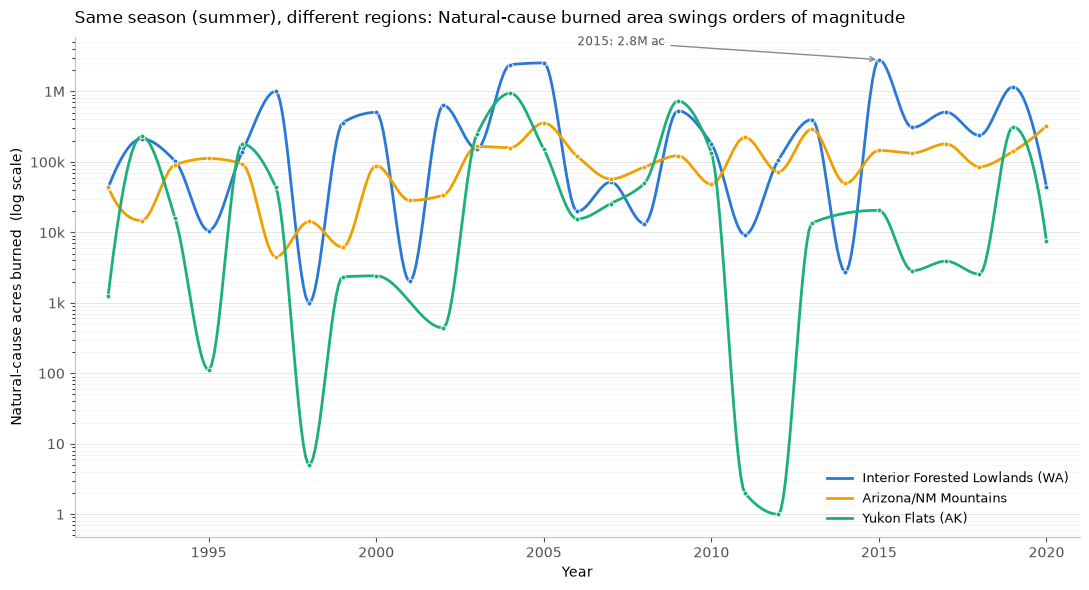

In [11]:
# Why the size of a Natural-cause season is so hard to predict: it swings wildly, and differently,
# from one region to the next. All three series are SUMMER (JJA) -- same season, different regions --
# so the contrast is purely region-to-region. LOG axis (the only way ~1-acre and ~2.8M-acre years fit
# on one figure). Lines are a monotone cubic (PCHIP) through the ACTUAL yearly points: purely cosmetic
# smoothing that never overshoots or invents a peak between years; every real value stays exactly on
# the line (the dots). The spikes -- the whole point -- are preserved, not averaged away.
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import PchipInterpolator

nat_ac = rsc[rsc["cause"] == "Natural"].groupby(["region", "season", "season_year"])["acres"].sum()

# Three summer regions chosen to contrast scale and volatility: a huge megafire-spiky one (carries
# the 2.8M-acre 2015 fire from the cell above), a steadier mid-scale one, and a high-volatility
# Alaskan boreal regime that plunges to near-zero in quiet years.
PICKS = [
    ("Interior Forested Lowlands (WA)", "Interior Forested Lowlands and Uplands", "JJA"),
    ("Arizona/NM Mountains",            "Arizona/New Mexico Mountains",           "JJA"),
    ("Yukon Flats (AK)",                "Yukon Flats",                            "JJA"),
]
YEARS = np.arange(1992, 2021)
COLORS = ["#2a78d6", "#eda100", "#1baf7a"]     # validated categorical slots (blue, yellow, aqua)

fig, ax = plt.subplots(figsize=(11, 6))
for (label, region, season), color in zip(PICKS, COLORS):
    y = nat_ac.loc[region, season].reindex(YEARS).clip(lower=1)    # log floor at 1 acre so gaps show
    obs = y.dropna()                                              # interpolate over years actually present
    xs = np.linspace(obs.index[0], obs.index[-1], 400)            # dense grid for a smooth curve
    ys = 10 ** PchipInterpolator(obs.index.to_numpy(), np.log10(obs.to_numpy()))(xs)   # in log space
    ax.plot(xs, ys, color=color, lw=2, zorder=3, label=label)
    ax.plot(obs.index, obs, ".", color=color, ms=7, mfc=color, mec="white", mew=0.6, zorder=4)

# Flag the 2015 Interior Forested megafire -- the case the interpretation cell calls out.
ifl = nat_ac.loc["Interior Forested Lowlands and Uplands", "JJA"].reindex(YEARS)
ax.annotate(f"2015: {ifl.max()/1e6:.1f}M ac", xy=(ifl.idxmax(), ifl.max()),
            xytext=(ifl.idxmax() - 9, ifl.max() * 1.6), fontsize=8.5, color="#52514e",
            arrowprops=dict(arrowstyle="->", color="#8a8a86", lw=1))

ax.set_yscale("log")
ax.set_ylabel("Natural-cause acres burned  (log scale)")
ax.set_xlabel("Year")
ax.set_title("Same season (summer), different regions: Natural-cause burned area swings orders of magnitude",
             fontsize=12, loc="left", pad=10)
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda v, _: f"{v/1e6:g}M" if v >= 1e6 else (f"{v/1e3:g}k" if v >= 1e3 else f"{v:g}")))
ax.set_xlim(1991, 2021)
ax.grid(True, which="major", axis="y", color="#e6e6e3", lw=0.7, zorder=0)
ax.grid(True, which="minor", axis="y", color="#f1f1ef", lw=0.5, zorder=0)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
for sp in ["left", "bottom"]:
    ax.spines[sp].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.legend(loc="lower right", frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

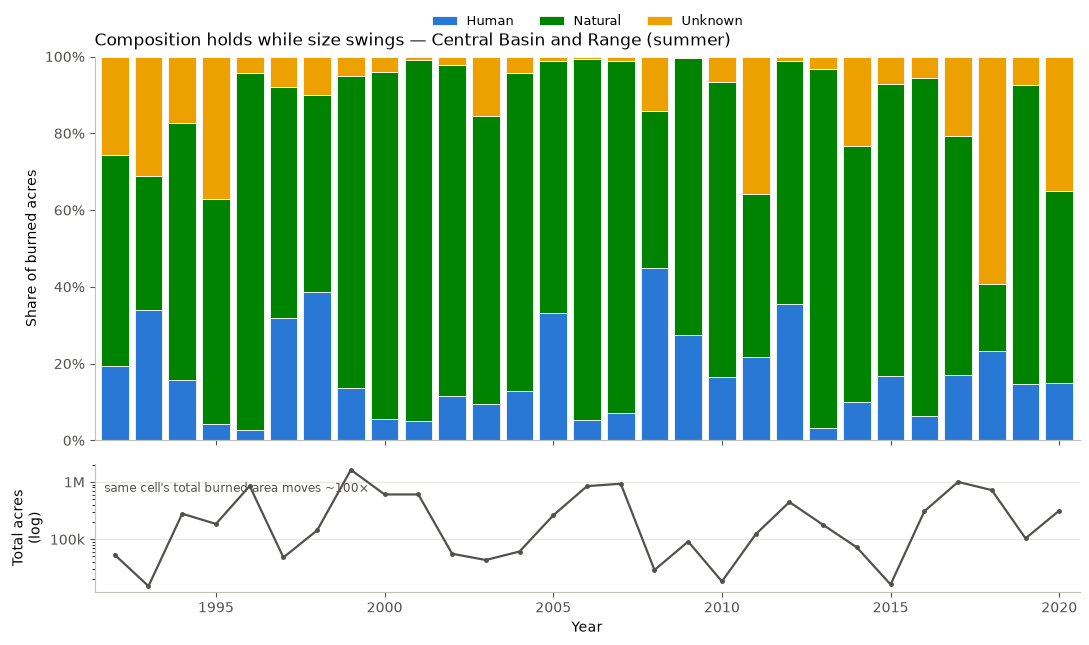

In [12]:
# The flip side of the plot above: while the SIZE of a season swings wildly, the cause COMPOSITION
# (the Human/Natural/Unknown share mix) is comparatively STABLE -- which is exactly why the shares
# baseline scores ~0.27 (predictable) while the level baseline is ~9x off (not). Shown on one
# region-season: the top panel is the mix (one stacked bar per year, roughly level bands), the
# bottom is that SAME cell's total acres (swinging ~100x on a log axis).
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

REGION, SEASON = "Central Basin and Range", "JJA"     # a big, megafire-prone region with a genuine
                                                      # three-way mix (not ~100% one class)
YEARS = np.arange(1992, 2021)

d = rsc[(rsc.region == REGION) & (rsc.season == SEASON)]
res = d.groupby(["season_year", "coarse"])["acres"].sum().unstack("coarse", fill_value=0.0)
res["Unknown"] = d.drop_duplicates(["season_year"]).set_index("season_year")["missing_acres"]
res = res.reindex(YEARS).fillna(0.0)
tot = res.sum(axis=1)
sh = res.div(tot, axis=0)[["Human", "Natural", "Unknown"]]    # stack: Human bottom, Natural mid, Unknown top

CLASS_COLORS = {"Human": "#2a78d6", "Natural": "#008300", "Unknown": "#eda100"}   # validated trio

fig, (ax, axb) = plt.subplots(2, 1, figsize=(11, 6.5), height_ratios=[3, 1], sharex=True)

# Top: one stacked bar per year -- the STABLE thing. Thin surface gaps between segments and bars.
bottom = np.zeros(len(YEARS))
for cls in ["Human", "Natural", "Unknown"]:
    ax.bar(YEARS, sh[cls], bottom=bottom, width=0.82, color=CLASS_COLORS[cls],
           label=cls, edgecolor="#fcfcfb", linewidth=0.6)
    bottom += sh[cls].to_numpy()
ax.set_ylim(0, 1)
ax.set_xlim(YEARS[0] - 0.6, YEARS[-1] + 0.6)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("Share of burned acres")
ax.set_title(f"Composition holds while size swings — {REGION} (summer)", fontsize=12, loc="left", pad=8)
ax.legend(loc="upper center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.14))
ax.tick_params(colors="#52514e")

# Bottom: the SAME region-season's total acres -- the UNSTABLE thing -- for direct contrast.
axb.plot(YEARS, tot.clip(lower=1), color="#52514e", lw=1.6, marker=".", ms=5)
axb.set_yscale("log")
axb.set_ylabel("Total acres\n(log)")
axb.yaxis.set_major_formatter(FuncFormatter(
    lambda v, _: f"{v/1e6:g}M" if v >= 1e6 else (f"{v/1e3:g}k" if v >= 1e3 else f"{v:g}")))
axb.set_xlabel("Year")
axb.grid(True, which="major", axis="y", color="#e6e6e3", lw=0.7)
axb.tick_params(colors="#52514e")
axb.text(0.01, 0.86, "same cell's total burned area moves ~100×", transform=axb.transAxes,
         fontsize=8.5, color="#52514e", va="top")

for a in (ax, axb):
    for sp in ["top", "right"]:
        a.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        a.spines[sp].set_color("#c3c2b7")

fig.tight_layout()
plt.show()

## The learned cross-sectional rung — can "what kind of region-season is this?" beat persistence?

The baselines above are the floor: they predict a cell purely from **its own past**. Their verdict
was that the cause *mix* is static (so a temporal model has nothing to exploit) but the *size* is
nearly unpredictable from history. The next rung looks for lift **cross-sectionally** instead —
predicting a region-season from *what kind of region-season it is*, letting similar cells inform
each other — using the trailing "fingerprint" features built in
[`05_features.ipynb`](05_features.ipynb) (`data/region_season_features.parquet`).

Every feature there is a strictly-prior trailing summary (the same forward-chaining discipline,
leakage-audited in that notebook), plus `season` as a non-leaking identity feature. We fit gradient-
boosted regressors on the **same forward-chaining split** (train `season_year < 2010`, score
`>= 2010`) and grade them with the **exact same metrics** as the floors — acre-weighted TVD for the
composition, acre-weighted log-MAE for the level — so the comparison is apples-to-apples. The
question this rung answers: does the fingerprint buy anything the k=7 / k=6 persistence means don't
already have?

**Next:** if this rung does not clear the floor by much, the reading is that the remaining lift is
not *in* the historical record at all — it is in the *upcoming* season's conditions (weather,
drought, fuels), which is exactly the external-data direction the branch notebooks open up.

In [13]:
# Load the cross-sectional feature table (built + leakage-audited in 05_features.ipynb).
# It carries the trailing fingerprint features AND the Tier-1 targets on the same rows, already
# filtered to the same partial-winter rule applied here.
feats = pd.read_parquet(DATA / "region_season_features.parquet")

# Align the persistence floor to the feature rows by KEY (not by position): attach the locked k=7
# shares prediction from the tier1 frame onto feats, so the head-to-head is guaranteed same-cell.
KEY = ["region", "season", "season_idx"]
floor_df = tier1[KEY].copy()
for c in CLASSES:
    floor_df[f"floor_{c}"] = pred_share[c].to_numpy()      # k=7 trailing-mean shares (locked baseline)
feats = feats.merge(floor_df, on=KEY, how="left")

FEATCOLS = [c for c in feats.columns if c.startswith("f_")]

# season is a legitimate, non-leaking identity feature (a cell knows its own season); one-hot it.
X_all = pd.get_dummies(feats[FEATCOLS + ["season"]], columns=["season"], dtype=float)
XCOLS = list(X_all.columns)

# Same forward-chaining split as the floors: train strictly before 2010, score 2010+.
train_mask = (feats["season_year"] < TEST_START).to_numpy()
test_mask  = (feats["season_year"] >= TEST_START).to_numpy()

# A cell is usable only where its trailing features exist (first-occurrence cells are NaN -- the
# same cells the baselines leave unscored, so both sides of the comparison see the identical tail).
has_feat = feats[FEATCOLS].notna().all(axis=1).to_numpy()
tr = train_mask & has_feat
te = test_mask  & has_feat

wt = feats["total_ac"].to_numpy()                      # acre weights (same weighting as the floors)
print(f"features: {len(XCOLS)} cols ({FEATCOLS} + season one-hot)")
print(f"train cells (<{TEST_START}, with history): {tr.sum():,}")
print(f"test  cells (>={TEST_START}, with history): {te.sum():,}")

features: 12 cols (['f_log_total_mean', 'f_log_total_std', 'f_share_human_mean', 'f_share_natural_mean', 'f_share_unknown_mean', 'f_log_fire_size_mean', 'f_log_nfires_mean', 'f_n_prior'] + season one-hot)
train cells (<2010, with history): 5,399
test  cells (>=2010, with history): 3,941


In [14]:
# LEARNED SHARES: one gradient-boosted regressor per class, predictions renormalized onto the
# simplex (clip negatives, divide by the row sum) so the three shares sum to 1 like the target.
# Scored with the SAME acre-weighted TVD as the floor, on the SAME test cells.
from sklearn.ensemble import HistGradientBoostingRegressor

Xtr = X_all.to_numpy()[tr]
Xte = X_all.to_numpy()[te]
Ytr = feats[CLASSES].to_numpy()[tr]

pred_parts = []
for j, c in enumerate(CLASSES):
    m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                      max_leaf_nodes=31, random_state=0)
    m.fit(Xtr, Ytr[:, j], sample_weight=wt[tr])        # weight training by acres too
    pred_parts.append(m.predict(Xte))
P_learn = np.clip(np.vstack(pred_parts).T, 0, None)
P_learn = P_learn / P_learn.sum(axis=1, keepdims=True)  # renormalize onto the simplex

A_te = feats[CLASSES].to_numpy()[te]                    # actual shares on the test cells
w_te = wt[te]

def tvd_score(P, A, w):
    tvd = 0.5 * np.abs(P - A).sum(axis=1)
    return tvd.mean(), np.average(tvd, weights=w)

# Persistence floor (locked k=7 shares mean), key-aligned onto the same feature rows above, so this
# is a head-to-head on identical cells.
P_floor = feats[[f"floor_{c}" for c in CLASSES]].to_numpy()[te]
floor_unw, floor_wtd = tvd_score(P_floor, A_te, w_te)
learn_unw, learn_wtd = tvd_score(P_learn, A_te, w_te)

shares_cmp = pd.DataFrame({
    "TVD_unweighted": [floor_unw, learn_unw],
    "TVD_acre_wtd":   [floor_wtd, learn_wtd],
}, index=["persistence floor (k=7)", "learned (gradient boosting)"])
shares_cmp["acre_wtd_delta_vs_floor"] = shares_cmp["TVD_acre_wtd"] - floor_wtd

print(f"SHARES — head-to-head on {te.sum():,} held-out cells (season_year >= {TEST_START})\n")
print(shares_cmp.round(4).to_string())
print(f"\nlower TVD = better. negative delta = learned beats the floor.")

SHARES — head-to-head on 3,941 held-out cells (season_year >= 2010)

                             TVD_unweighted  TVD_acre_wtd  acre_wtd_delta_vs_floor
persistence floor (k=7)              0.2676        0.2659                   0.0000
learned (gradient boosting)          0.3141        0.2894                   0.0235

lower TVD = better. negative delta = learned beats the floor.


In [15]:
# LEARNED LEVEL: a gradient-boosted regressor on log10(total_ac), scored with the SAME acre-weighted
# log-MAE as the level floor. This is the hard target -- the floor was ~9x off on the big-burn cells.

# Attach the level floor (its own best trailing window, computed in the level sweep) by key.
lvl_floor_df = tier1[KEY].copy()
lvl_floor_df["floor_log"] = pred_log.to_numpy()        # trailing-mean log-acres (level baseline)
lvl_floor_df["actual_log"] = tier1["log_total"].to_numpy()
feats2 = feats.merge(lvl_floor_df, on=KEY, how="left")

ytr_log = feats2["actual_log"].to_numpy()[tr]
yte_log = feats2["actual_log"].to_numpy()[te]

mlvl = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05,
                                     max_leaf_nodes=31, random_state=0)
mlvl.fit(Xtr, ytr_log, sample_weight=wt[tr])
pred_log_learn = mlvl.predict(Xte)
pred_log_floor = feats2["floor_log"].to_numpy()[te]

def logmae(pred, actual, w):
    err = np.abs(pred - actual)
    return err.mean(), np.average(err, weights=w)

fl_unw, fl_wtd = logmae(pred_log_floor, yte_log, w_te)
ln_unw, ln_wtd = logmae(pred_log_learn, yte_log, w_te)

level_cmp = pd.DataFrame({
    "logMAE_unweighted": [fl_unw, ln_unw],
    "logMAE_acre_wtd":   [fl_wtd, ln_wtd],
    "acre_wtd_x_off":    [10 ** fl_wtd, 10 ** ln_wtd],     # read as "typically off by ~Nx"
}, index=[f"persistence floor ({best_level})", "learned (gradient boosting)"])
level_cmp["acre_wtd_delta_vs_floor"] = level_cmp["logMAE_acre_wtd"] - fl_wtd

print(f"LEVEL — head-to-head on {te.sum():,} held-out cells (season_year >= {TEST_START})\n")
print(level_cmp.round(4).to_string())
print(f"\nlower log-MAE = better. negative delta = learned beats the floor.")

LEVEL — head-to-head on 3,941 held-out cells (season_year >= 2010)

                             logMAE_unweighted  logMAE_acre_wtd  acre_wtd_x_off  acre_wtd_delta_vs_floor
persistence floor (k=6)                 0.6352           0.9347          8.6033                    0.000
learned (gradient boosting)             0.9641           0.7767          5.9794                   -0.158

lower log-MAE = better. negative delta = learned beats the floor.


In [16]:
# Ablation verdict — read the two deltas and state the outcome in plain terms.
sh_delta = shares_cmp.loc["learned (gradient boosting)", "acre_wtd_delta_vs_floor"]
lv_delta = level_cmp.loc["learned (gradient boosting)", "acre_wtd_delta_vs_floor"]

def verdict(delta, floor_val, unit):
    pct = 100 * delta / floor_val
    if delta < -0.005:
        return f"BEATS the floor by {abs(delta):.3f} {unit} ({abs(pct):.1f}% better)"
    if delta > 0.005:
        return f"does NOT beat the floor (worse by {delta:.3f} {unit})"
    return f"TIES the floor (delta {delta:+.3f} {unit}, within noise)"

print("ABLATION LADDER — learned cross-sectional rung vs. persistence floor (acre-weighted)\n")
print(f"  SHARES (cause mix): learned {verdict(sh_delta, floor_wtd, 'TVD')}")
print(f"  LEVEL  (burn size): learned {verdict(lv_delta, fl_wtd, 'log-MAE')}")
print()
print("Reading: a tie on shares confirms the mix signal is already captured by the trailing mean")
print("(the target is static); a tie on the level confirms the missing lift is NOT in the history")
print("-> it points to upcoming-season covariates (weather/drought/fuels), the next rung.")

ABLATION LADDER — learned cross-sectional rung vs. persistence floor (acre-weighted)

  SHARES (cause mix): learned does NOT beat the floor (worse by 0.024 TVD)
  LEVEL  (burn size): learned BEATS the floor by 0.158 log-MAE (16.9% better)

Reading: a tie on shares confirms the mix signal is already captured by the trailing mean
(the target is static); a tie on the level confirms the missing lift is NOT in the history
-> it points to upcoming-season covariates (weather/drought/fuels), the next rung.
